# The Simpsons
By: pierremegret

## Download Dataset from Kaggle

In [12]:
# source: https://www.kaggle.com/discussions/general/74235
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

#! kaggle kernels pull ambarish/fun-in-text-mining-with-simpsons
!kaggle datasets download -d pierremegret/dialogue-lines-of-the-simpsons

! unzip "*.zip"

Dataset URL: https://www.kaggle.com/datasets/pierremegret/dialogue-lines-of-the-simpsons
License(s): CC-BY-SA-3.0
100% 3.32M/3.32M [00:00<00:00, 157MB/s]

Archive:  dialogue-lines-of-the-simpsons.zip
  inflating: simpsons_dataset.csv    


In [7]:
import re  # For preprocessing
import pandas as pd  # For data handling
from time import time  # To time our operations
from collections import defaultdict  # For word frequency

import spacy  # For preprocessing

import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)


In [14]:
df = pd.read_csv('simpsons_dataset.csv')
df.shape

(158314, 2)

In [ ]:
twigen.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,...,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,...,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,...,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade,i absolutely adore when louis starts the songs...,louis whining and squealing and all
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0000,yes,1.0,6/11/09 22:39,...,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0000,yes,1.0,4/16/14 13:23,...,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...


Let's grab some info about the gold standard and about the dataset's confidence in its gender classifications so we have some idea of what would be good to train on.

In [ ]:

# how many observations are gold standard?
# golden values(True,False) mean that the entry is 100% reliable and verified
# Source: https://www.geeksforgeeks.org/python/defaultdict-in-python/

# golden_values = labeled by domain experts
# confidence = how many people agree that an entry is reliable
gold_values = defaultdict(int)
for val in twigen._golden:
    gold_values[val] += 1
print(gold_values)

print(np.any(np.isnan(twigen['gender:confidence']))) # what does the confidence look like?

gender_confidence = twigen['gender:confidence'][
    np.where(np.invert(np.isnan(twigen['gender:confidence'])))[0]] # we've got at least one NaN, so let's remove

print(len(gender_confidence))

# IMPORTANT: Debug the lines below
#gender_nonones = gender_confidence[np.where(gender_confidence < 1)[0]]
#print(len(gender_nonones))

defaultdict(<class 'int'>, {False: 20000, True: 50})
True
20024


About 30% of the observations have less than 100% confidence in the gender classification, so we'll ignore those.

In [ ]:
twigen_confident = twigen[twigen['gender:confidence']==1] # twigen is a pd object, the syntax gets only entries with 1 confidence
print(twigen_confident.shape)

# shows that there are not NaN confidence values
print(np.any(np.isnan(twigen_confident['gender:confidence']))) # There should be no NaN params due the action above.

# Now, we need to get rid of the rows that contain the gender type "unknown" and "brand"
# by explicitly selecting gender values that are in "male" or "female"
twigen_confident = twigen_confident[twigen_confident['gender'].isin(['male','female'])]
print(twigen_confident.shape)

print(twigen_confident['gender'].value_counts())

twigen_confident.head()

(13926, 29)
False
(10020, 29)
gender
female    5367
male      4653
Name: count, dtype: int64


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm,all_features
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0,yes,1.0,12/5/13 1:48,...,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.,robbie e responds to critics after win against...
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0,yes,1.0,10/1/12 13:51,...,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...,ûïit felt like they were my friends and i was...
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0,yes,1.0,6/11/09 22:39,...,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...,hi jordanspieth looking at the url do you use ...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0,yes,1.0,4/16/14 13:23,...,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...,watching neighbours on sky catching up with th...
5,815719231,False,finalized,3,10/27/15 1:47,female,1.0,yes,1.0,3/11/10 18:14,...,"Ive seen people on the train with lamps, chair...",NaN,20036,10/26/15 12:40,6.587300e+17,New York Gritty,Central Time (US & Canada),ive seen people on the train with lamps chairs...,you don't know me.,ive seen people on the train with lamps chairs...


Okay, now let's see how well a Naive Bayes classifier can do by just looking at the words in the randomly chosen tweet.

In [ ]:
# pull the data into vectors
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(twigen_confident['text_norm'])

encoder = LabelEncoder()
y = encoder.fit_transform(twigen_confident['gender'])
print(encoder.classes_)

# split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# take a look at the shape of each of these
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


['female' 'male']
(8016, 25151)
(8016,)
(2004, 25151)
(2004,)


# Training

In [ ]:
nb = MultinomialNB()
nb.fit(x_train, y_train)

print(nb.score(x_test, y_test))

0.6202594810379242


So we get about 62% accuracy on the "best" observations, using only tweet text.

Let's try a couple more features. Specifically, let's add the description text by concatenating it to the tweet text.

In [ ]:
twigen_confident['all_features'] = twigen_confident['text_norm'].str.cat(twigen_confident['description_norm'], sep=' ')
twigen_confident.head()
#twigen_confident = twigen[twigen['gender:confidence']==1]

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm,all_features
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0,yes,1.0,12/5/13 1:48,...,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.,robbie e responds to critics after win against...
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0,yes,1.0,10/1/12 13:51,...,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...,ûïit felt like they were my friends and i was...
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0,yes,1.0,6/11/09 22:39,...,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...,hi jordanspieth looking at the url do you use ...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0,yes,1.0,4/16/14 13:23,...,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...,watching neighbours on sky catching up with th...
5,815719231,False,finalized,3,10/27/15 1:47,female,1.0,yes,1.0,3/11/10 18:14,...,"Ive seen people on the train with lamps, chair...",NaN,20036,10/26/15 12:40,6.587300e+17,New York Gritty,Central Time (US & Canada),ive seen people on the train with lamps chairs...,you don't know me.,ive seen people on the train with lamps chairs...


In [ ]:
# pull the data into vectors
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(twigen_confident['all_features'])

encoder = LabelEncoder()
y = encoder.fit_transform(twigen_confident['gender'])
print(encoder.classes_)

# split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

nb = MultinomialNB()
nb.fit(x_train, y_train)

print(nb.score(x_test, y_test))

['female' 'male']
0.7055888223552894


Cool, so we gain about 2-3 percentage points in accuracy just by adding description text alongside tweet text.

You can use this kind of procedure to play around with adding more features, or try a different type of model and see how accurately you can predict gender. (Maybe also try including the less-confident observations; my exclusion of them was probably anti-conservative)

# Visualizations and Reports

In [ ]:
predicted = nb.predict(x_test)

print(
    f"Classification report for Kaggle dataset:\n"
    f"{metrics.classification_report(y_test, predicted, target_names=encoder.classes_)}\n"
)

Classification report for Kaggle dataset:
              precision    recall  f1-score   support

      female       0.69      0.79      0.74      1090
        male       0.70      0.57      0.63       914

    accuracy                           0.69      2004
   macro avg       0.69      0.68      0.68      2004
weighted avg       0.69      0.69      0.69      2004




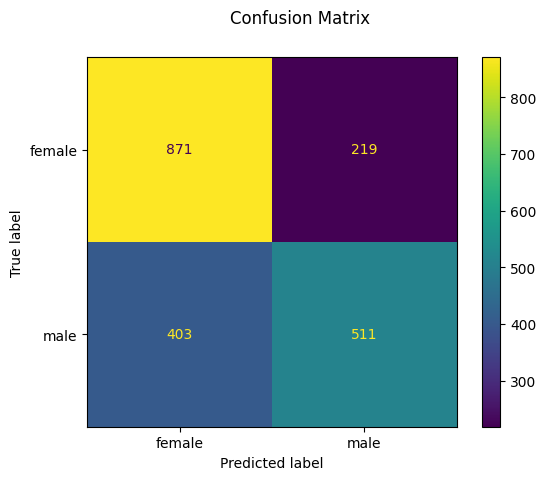

In [ ]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, predicted, display_labels=encoder.classes_)
disp.figure_.suptitle("Confusion Matrix")

plt.show()